In [2]:
# ============================================
# CELL 1: IMPORT THƯ VIỆN
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os

print("✅ Đã import tất cả thư viện!")

✅ Đã import tất cả thư viện!


In [3]:
# ============================================
# CELL 2: ĐỌC DỮ LIỆU
# ============================================

DATA_DIR = '../data/raw'
sales = pd.read_csv(os.path.join(DATA_DIR, "sales.csv"), parse_dates=["Date"])

print("="*50)
print("DỮ LIỆU GỐC")
print("="*50)
print(f"Shape: {sales.shape}")
print(f"Từ ngày: {sales['Date'].min().date()} → {sales['Date'].max().date()}")
print("\n5 dòng đầu:")
print(sales.head())

print("\n" + "="*50)
print("THÔNG TIN DỮ LIỆU")
print("="*50)
print(sales.info())

DỮ LIỆU GỐC
Shape: (3833, 3)
Từ ngày: 2012-07-04 → 2022-12-31

5 dòng đầu:
        Date     Revenue        COGS
0 2012-07-04  5123547.94  3982991.19
1 2012-07-05  2751773.45  2150580.23
2 2012-07-06  3054029.42  2517632.84
3 2012-07-07  2667930.94  2108246.62
4 2012-07-08  2360851.90  1808622.79

THÔNG TIN DỮ LIỆU
<class 'pandas.DataFrame'>
RangeIndex: 3833 entries, 0 to 3832
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     3833 non-null   datetime64[us]
 1   Revenue  3833 non-null   float64       
 2   COGS     3833 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 90.0 KB
None


In [4]:
# ============================================
# CELL 3: KIỂM TRA DỮ LIỆU BỊ THIẾU (MISSING VALUES)
# ============================================

print("\n" + "="*50)
print("KIỂM TRA DỮ LIỆU BỊ THIẾU")
print("="*50)

missing = sales.isnull().sum()
missing_pct = (missing / len(sales)) * 100

missing_df = pd.DataFrame({
    'Cột': missing.index,
    'Số lượng missing': missing.values,
    'Tỷ lệ (%)': missing_pct.values
})

print(missing_df[missing_df['Số lượng missing'] > 0])

if missing.sum() == 0:
    print("\n✅ Không có dữ liệu bị thiếu!")
else:
    print("\n⚠️ Có dữ liệu bị thiếu, cần xử lý!")


KIỂM TRA DỮ LIỆU BỊ THIẾU
Empty DataFrame
Columns: [Cột, Số lượng missing, Tỷ lệ (%)]
Index: []

✅ Không có dữ liệu bị thiếu!



PHÂN TÍCH OUTLIER - REVENUE

📊 Thống kê Revenue:
count    3.833000e+03
mean     4.286584e+06
std      2.624840e+06
min      2.798139e+05
25%      2.471089e+06
50%      3.647304e+06
75%      5.350877e+06
max      2.090527e+07
Name: Revenue, dtype: float64


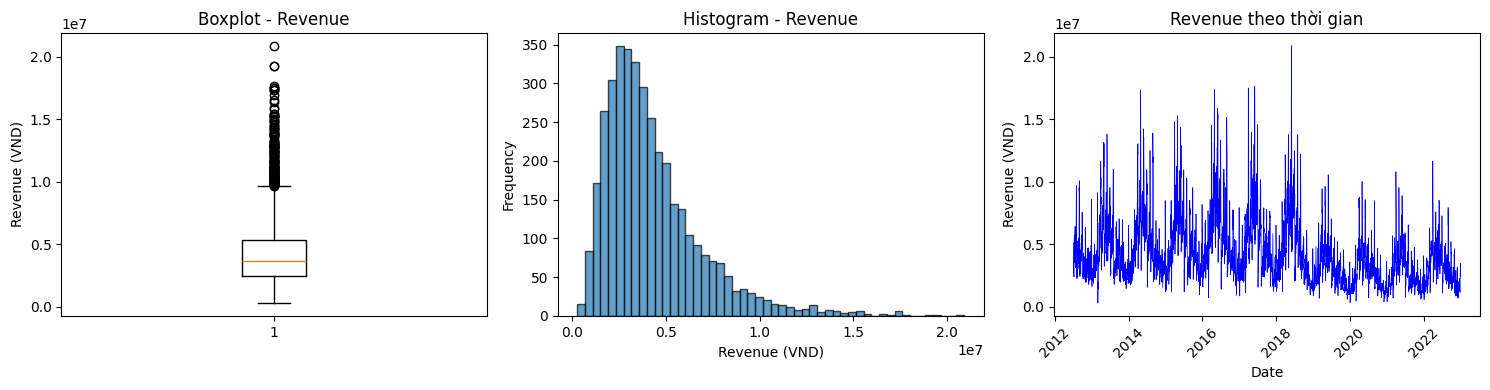


📊 Số lượng outlier trong Revenue: 169 (4.41%)
   Ngưỡng dưới: -1,848,594 VND
   Ngưỡng trên: 9,670,560 VND
   Min outlier: 9,681,622 VND
   Max outlier: 20,905,271 VND


In [5]:
# ============================================
# CELL 4: PHÂN TÍCH OUTLIER - REVENUE
# ============================================

print("\n" + "="*50)
print("PHÂN TÍCH OUTLIER - REVENUE")
print("="*50)

# Thống kê cơ bản
print("\n📊 Thống kê Revenue:")
print(sales['Revenue'].describe())

# Vẽ boxplot để phát hiện outlier
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
axes[0].boxplot(sales['Revenue'])
axes[0].set_title('Boxplot - Revenue')
axes[0].set_ylabel('Revenue (VND)')

# Histogram
axes[1].hist(sales['Revenue'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Histogram - Revenue')
axes[1].set_xlabel('Revenue (VND)')
axes[1].set_ylabel('Frequency')

# Line plot theo thời gian
axes[2].plot(sales['Date'], sales['Revenue'], 'b-', linewidth=0.5)
axes[2].set_title('Revenue theo thời gian')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('Revenue (VND)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Xác định outlier bằng IQR method
Q1 = sales['Revenue'].quantile(0.25)
Q3 = sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_rev = sales[(sales['Revenue'] < lower_bound) | (sales['Revenue'] > upper_bound)]
print(f"\n📊 Số lượng outlier trong Revenue: {len(outliers_rev)} ({len(outliers_rev)/len(sales)*100:.2f}%)")
print(f"   Ngưỡng dưới: {lower_bound:,.0f} VND")
print(f"   Ngưỡng trên: {upper_bound:,.0f} VND")
print(f"   Min outlier: {outliers_rev['Revenue'].min():,.0f} VND")
print(f"   Max outlier: {outliers_rev['Revenue'].max():,.0f} VND")


PHÂN TÍCH OUTLIER - COGS

📊 Thống kê COGS:
count    3.833000e+03
mean     3.695134e+06
std      2.219789e+06
min      2.365763e+05
25%      2.150580e+06
50%      3.161113e+06
75%      4.637294e+06
max      1.653586e+07
Name: COGS, dtype: float64


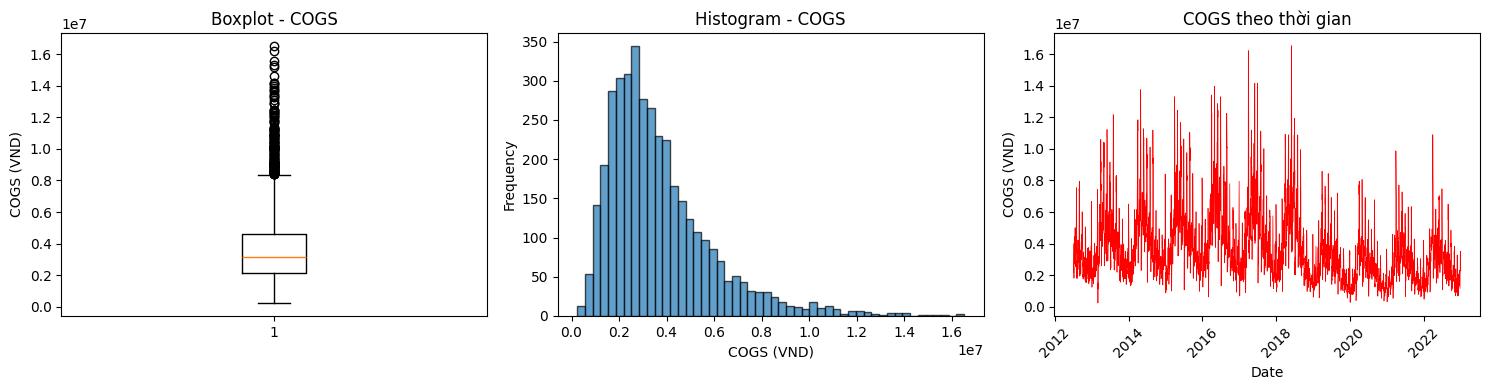


📊 Số lượng outlier trong COGS: 165 (4.30%)
   Ngưỡng dưới: -1,579,490 VND
   Ngưỡng trên: 8,367,364 VND


In [6]:
# ============================================
# CELL 5: PHÂN TÍCH OUTLIER - COGS
# ============================================

print("\n" + "="*50)
print("PHÂN TÍCH OUTLIER - COGS")
print("="*50)

# Thống kê cơ bản
print("\n📊 Thống kê COGS:")
print(sales['COGS'].describe())

# Vẽ boxplot
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Boxplot
axes[0].boxplot(sales['COGS'])
axes[0].set_title('Boxplot - COGS')
axes[0].set_ylabel('COGS (VND)')

# Histogram
axes[1].hist(sales['COGS'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title('Histogram - COGS')
axes[1].set_xlabel('COGS (VND)')
axes[1].set_ylabel('Frequency')

# Line plot theo thời gian
axes[2].plot(sales['Date'], sales['COGS'], 'r-', linewidth=0.5)
axes[2].set_title('COGS theo thời gian')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('COGS (VND)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Xác định outlier bằng IQR method
Q1 = sales['COGS'].quantile(0.25)
Q3 = sales['COGS'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_cogs = sales[(sales['COGS'] < lower_bound) | (sales['COGS'] > upper_bound)]
print(f"\n📊 Số lượng outlier trong COGS: {len(outliers_cogs)} ({len(outliers_cogs)/len(sales)*100:.2f}%)")
print(f"   Ngưỡng dưới: {lower_bound:,.0f} VND")
print(f"   Ngưỡng trên: {upper_bound:,.0f} VND")

In [7]:
# ============================================
# CELL 6: XỬ LÝ OUTLIER
# ============================================

print("\n" + "="*50)
print("XỬ LÝ OUTLIER")
print("="*50)

# Tạo bản sao để xử lý
sales_cleaned = sales.copy()

# CÁCH 1: CẮT (CAPPING) - Thay thế outlier bằng ngưỡng
# Đây là cách phổ biến nhất cho dữ liệu tài chính

print("\n📊 Cách 1: Capping (thay thế bằng ngưỡng)")

# Xử lý Revenue
Q1_rev = sales['Revenue'].quantile(0.25)
Q3_rev = sales['Revenue'].quantile(0.75)
IQR_rev = Q3_rev - Q1_rev
lower_rev = Q1_rev - 1.5 * IQR_rev
upper_rev = Q3_rev + 1.5 * IQR_rev

sales_cleaned['Revenue_capped'] = sales_cleaned['Revenue'].clip(lower=lower_rev, upper=upper_rev)

# Xử lý COGS
Q1_cogs = sales['COGS'].quantile(0.25)
Q3_cogs = sales['COGS'].quantile(0.75)
IQR_cogs = Q3_cogs - Q1_cogs
lower_cogs = Q1_cogs - 1.5 * IQR_cogs
upper_cogs = Q3_cogs + 1.5 * IQR_cogs

sales_cleaned['COGS_capped'] = sales_cleaned['COGS'].clip(lower=lower_cogs, upper=upper_cogs)

print(f"✅ Đã capping Revenue: thay thế {len(outliers_rev)} outlier")
print(f"✅ Đã capping COGS: thay thế {len(outliers_cogs)} outlier")

# So sánh trước và sau xử lý
print("\n📊 So sánh thống kê trước và sau khi xử lý:")
print("\nREVENUE:")
print(f"   Mean trước: {sales['Revenue'].mean():,.0f}")
print(f"   Mean sau:   {sales_cleaned['Revenue_capped'].mean():,.0f}")
print(f"   Std trước:  {sales['Revenue'].std():,.0f}")
print(f"   Std sau:    {sales_cleaned['Revenue_capped'].std():,.0f}")

print("\nCOGS:")
print(f"   Mean trước: {sales['COGS'].mean():,.0f}")
print(f"   Mean sau:   {sales_cleaned['COGS_capped'].mean():,.0f}")
print(f"   Std trước:  {sales['COGS'].std():,.0f}")
print(f"   Std sau:    {sales_cleaned['COGS_capped'].std():,.0f}")


XỬ LÝ OUTLIER

📊 Cách 1: Capping (thay thế bằng ngưỡng)
✅ Đã capping Revenue: thay thế 169 outlier
✅ Đã capping COGS: thay thế 165 outlier

📊 So sánh thống kê trước và sau khi xử lý:

REVENUE:
   Mean trước: 4,286,584
   Mean sau:   4,170,524
   Std trước:  2,624,840
   Std sau:    2,256,091

COGS:
   Mean trước: 3,695,134
   Mean sau:   3,602,482
   Std trước:  2,219,789
   Std sau:    1,926,942



LOG TRANSFORMATION (Giảm ảnh hưởng của outlier)


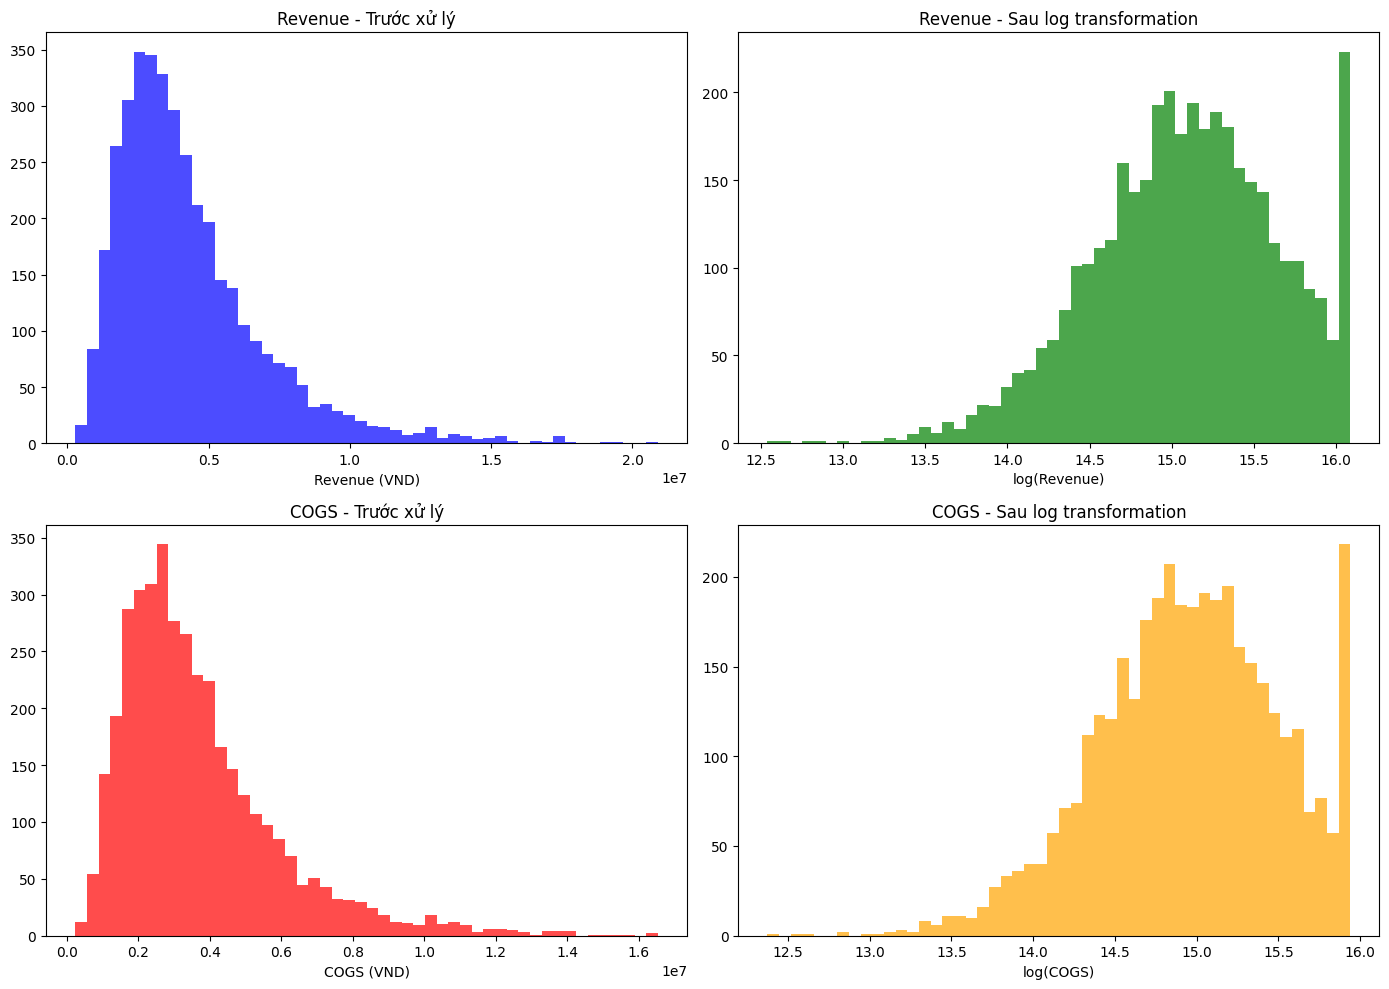

✅ Log transformation giúp phân phối dữ liệu gần với phân phối chuẩn hơn!


In [8]:
# ============================================
# CELL 7: CÁCH 2 - LOG TRANSFORMATION (GIẢM ẢNH HƯỞNG CỦA OUTLIER)
# ============================================

print("\n" + "="*50)
print("LOG TRANSFORMATION (Giảm ảnh hưởng của outlier)")
print("="*50)

# Log transformation
sales_cleaned['Revenue_log'] = np.log1p(sales_cleaned['Revenue_capped'])
sales_cleaned['COGS_log'] = np.log1p(sales_cleaned['COGS_capped'])

# Vẽ so sánh trước và sau log
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue before vs after
axes[0, 0].hist(sales['Revenue'], bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('Revenue - Trước xử lý')
axes[0, 0].set_xlabel('Revenue (VND)')

axes[0, 1].hist(sales_cleaned['Revenue_log'], bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('Revenue - Sau log transformation')
axes[0, 1].set_xlabel('log(Revenue)')

# COGS before vs after
axes[1, 0].hist(sales['COGS'], bins=50, alpha=0.7, color='red')
axes[1, 0].set_title('COGS - Trước xử lý')
axes[1, 0].set_xlabel('COGS (VND)')

axes[1, 1].hist(sales_cleaned['COGS_log'], bins=50, alpha=0.7, color='orange')
axes[1, 1].set_title('COGS - Sau log transformation')
axes[1, 1].set_xlabel('log(COGS)')

plt.tight_layout()
plt.show()

print("✅ Log transformation giúp phân phối dữ liệu gần với phân phối chuẩn hơn!")

In [9]:
# ============================================
# CELL 8: KIỂM TRA LẠI OUTLIER SAU KHI XỬ LÝ
# ============================================

print("\n" + "="*50)
print("KIỂM TRA LẠI SAU XỬ LÝ")
print("="*50)

# Kiểm tra outlier trong dữ liệu đã xử lý (capped)
outliers_rev_capped = sales_cleaned[(sales_cleaned['Revenue_capped'] < lower_rev) | 
                                    (sales_cleaned['Revenue_capped'] > upper_rev)]
outliers_cogs_capped = sales_cleaned[(sales_cleaned['COGS_capped'] < lower_cogs) | 
                                     (sales_cleaned['COGS_capped'] > upper_cogs)]

print(f"\n📊 Revenue - Số lượng outlier sau capping: {len(outliers_rev_capped)} (phải = 0)")
print(f"📊 COGS - Số lượng outlier sau capping: {len(outliers_cogs_capped)} (phải = 0)")

if len(outliers_rev_capped) == 0 and len(outliers_cogs_capped) == 0:
    print("\n✅ OUTLIER ĐÃ ĐƯỢC XỬ LÝ THÀNH CÔNG!")
else:
    print("\n⚠️ Vẫn còn outlier, cần xử lý thêm!")


KIỂM TRA LẠI SAU XỬ LÝ

📊 Revenue - Số lượng outlier sau capping: 0 (phải = 0)
📊 COGS - Số lượng outlier sau capping: 0 (phải = 0)

✅ OUTLIER ĐÃ ĐƯỢC XỬ LÝ THÀNH CÔNG!



TẠO DATASET CUỐI CÙNG
✅ Đã tạo 2 phiên bản dữ liệu sạch:
   1. sales_final.csv - Dữ liệu đã capping outlier
   2. sales_log.csv - Dữ liệu đã log transformation

📊 Thống kê dữ liệu đã xử lý (capped):
                      Date       Revenue          COGS
count                 3833  3.833000e+03  3.833000e+03
mean   2017-10-02 00:00:00  4.170524e+06  3.602482e+06
min    2012-07-04 00:00:00  2.798139e+05  2.365763e+05
25%    2015-02-17 00:00:00  2.471089e+06  2.150580e+06
50%    2017-10-02 00:00:00  3.647304e+06  3.161113e+06
75%    2020-05-17 00:00:00  5.350877e+06  4.637294e+06
max    2022-12-31 00:00:00  9.670560e+06  8.367364e+06
std                    NaN  2.256091e+06  1.926942e+06


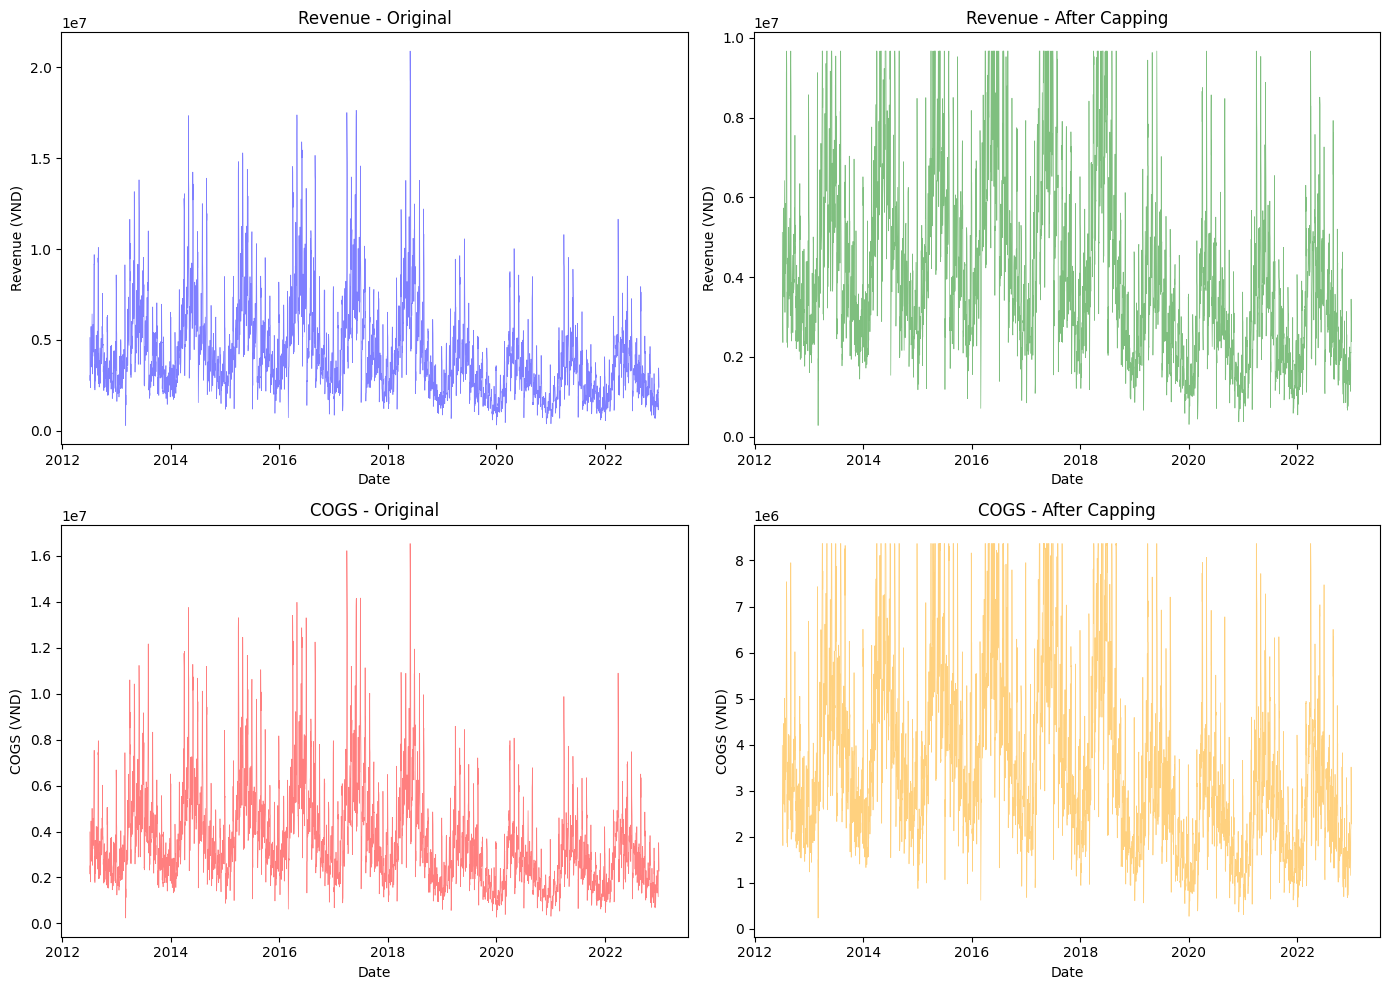


✅ Đã lưu biểu đồ so sánh: data_cleaning_comparison.png


In [10]:
# ============================================
# CELL 9: TẠO DATASET CUỐI CÙNG
# ============================================

print("\n" + "="*50)
print("TẠO DATASET CUỐI CÙNG")
print("="*50)

# Tạo dataset sạch để train
sales_final = sales_cleaned[['Date', 'Revenue_capped', 'COGS_capped']].copy()
sales_final.columns = ['Date', 'Revenue', 'COGS']

# Cũng tạo version log nếu cần
sales_log = sales_cleaned[['Date', 'Revenue_log', 'COGS_log']].copy()
sales_log.columns = ['Date', 'Revenue', 'COGS']

print("✅ Đã tạo 2 phiên bản dữ liệu sạch:")
print("   1. sales_final.csv - Dữ liệu đã capping outlier")
print("   2. sales_log.csv - Dữ liệu đã log transformation")

# Lưu file
sales_final.to_csv('../data/processed/sales_cleaned.csv', index=False)
sales_log.to_csv('../data/processed/sales_log.csv', index=False)

print("\n📊 Thống kê dữ liệu đã xử lý (capped):")
print(sales_final.describe())

# Vẽ so sánh cuối cùng
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Revenue original vs cleaned
axes[0, 0].plot(sales['Date'], sales['Revenue'], 'b-', alpha=0.5, label='Original', linewidth=0.5)
axes[0, 0].set_title('Revenue - Original')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Revenue (VND)')

axes[0, 1].plot(sales_final['Date'], sales_final['Revenue'], 'g-', alpha=0.5, label='Cleaned', linewidth=0.5)
axes[0, 1].set_title('Revenue - After Capping')
axes[0, 1].set_xlabel('Date')
axes[0, 1].set_ylabel('Revenue (VND)')

# COGS original vs cleaned
axes[1, 0].plot(sales['Date'], sales['COGS'], 'r-', alpha=0.5, label='Original', linewidth=0.5)
axes[1, 0].set_title('COGS - Original')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('COGS (VND)')

axes[1, 1].plot(sales_final['Date'], sales_final['COGS'], 'orange', alpha=0.5, label='Cleaned', linewidth=0.5)
axes[1, 1].set_title('COGS - After Capping')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('COGS (VND)')

plt.tight_layout()
plt.savefig('data_cleaning_comparison.png', dpi=100)
plt.show()

print("\n✅ Đã lưu biểu đồ so sánh: data_cleaning_comparison.png")

In [11]:
# ============================================
# CELL 10: PHÂN TÍCH IMBALANCE (MẤT CÂN BẰNG DỮ LIỆU)
# ============================================

print("\n" + "="*50)
print("PHÂN TÍCH IMBALANCE (dữ liệu có mất cân bằng không?)")
print("="*50)

# Tính tỷ lệ thay đổi theo ngày
sales_final['Revenue_change'] = sales_final['Revenue'].pct_change()
sales_final['COGS_change'] = sales_final['COGS'].pct_change()

# Phân phối của revenue
print("\n📊 Phân phối Revenue:")
print(f"   Mean: {sales_final['Revenue'].mean():,.0f}")
print(f"   Median: {sales_final['Revenue'].median():,.0f}")
print(f"   Std: {sales_final['Revenue'].std():,.0f}")
print(f"   Skewness (độ lệch): {sales_final['Revenue'].skew():.4f}")
print(f"   Kurtosis (độ nhọn): {sales_final['Revenue'].kurtosis():.4f}")

if abs(sales_final['Revenue'].skew()) > 1:
    print("   ⚠️ Dữ liệu Revenue bị lệch (skew), có thể ảnh hưởng đến model")
else:
    print("   ✅ Dữ liệu Revenue tương đối cân bằng")

# Phân phối của log revenue
print("\n📊 Phân phối Revenue (sau log):")
log_rev = np.log1p(sales_final['Revenue'])
print(f"   Skewness: {log_rev.skew():.4f}")
print(f"   Kurtosis: {log_rev.kurtosis():.4f}")

if abs(log_rev.skew()) < 0.5:
    print("   ✅ Log transformation giúp dữ liệu cân bằng hơn!")


PHÂN TÍCH IMBALANCE (dữ liệu có mất cân bằng không?)

📊 Phân phối Revenue:
   Mean: 4,170,524
   Median: 3,647,304
   Std: 2,256,091
   Skewness (độ lệch): 0.8675
   Kurtosis (độ nhọn): 0.0429
   ✅ Dữ liệu Revenue tương đối cân bằng

📊 Phân phối Revenue (sau log):
   Skewness: -0.3463
   Kurtosis: 0.0122
   ✅ Log transformation giúp dữ liệu cân bằng hơn!
